# Atlas: End-to-End Pipeline
Este notebook executa o pipeline completo utilizando `configs/base.yaml`, gerando os resultados de backtest e walk-forward, comparando com o índice Ibovespa e exibindo KPIs resumidos.

**Roteiro do notebook:**
1. **Contexto da estratégia**: resume universo, sinais, construção de portfólio, gestão de risco e premissas de custo.
2. **Carregamento de configurações e painel**: carrega `configs/base.yaml`, monta o painel de preços/volumes e valida o recorte temporal.
3. **Qualidade e composição dos dados**: consolida checks de cobertura, duplicidade, nulos e liquidez do universo.
4. **Execução do backtest e walk-forward referência**: roda o pipeline base (janelas 504/126) para obter curva e KPIs de referência.
5. **Benchmark Ibovespa**: prepara a série normalizada do índice como baseline de mercado.
6. **Curvas de equity e KPIs agregados**: plota backtest/walk-forward/benchmark e sintetiza CAGR, Sharpe/Sortino em excesso ? Selic, volatilidade e drawdown.
7. **KPIs por janela de walk-forward**: detalha métricas por janela out-of-sample para avaliar consistência temporal.
8. **Cenário adicional de risco**: reexecuta o walk-forward com `target_vol=0.14` e `vol_mult=1.4` como alternativa mais conservadora.
9. **Comparação das curvas e KPIs**: confronta base vs cenário alternativo e exibe deltas de performance.
10. **Testes de robustez e sensibilidade**: roda stress de custos e resume os principais pontos dos heatmaps de parâmetros.
11. **Robustez visual**: organiza heatmaps e stress tests em gráficos para argumentação visual.
12. **Intervalos de confiança para KPIs**: aplica bootstrap em blocos (21 dias) para quantis de CAGR, Sharpe e MaxDD.
13. **Interpretação dos testes**: traduz intervalos, PSR e p-values em implicações práticas para cada cenário.
14. **Conclusões**: destaca trade-offs de risco/retorno, significância estatística e robustez observada.


### 1. Contexto da estratégia
Atlas é um pipeline de alocação long-only para o universo brasileiro, combinando heurísticas topológicas e fatores clássicos para entregar risco equilibrado em múltiplos regimes. A seguir resumimos as premissas que embasam os resultados apresentados.

- **Universo e dados**: trabalhamos com os constituintes do Ibovespa em cada quadrimestre, filtrando os 20 ativos mais líquidos (ADV > BRL 500k, preço > BRL 5, idade > 20 pregões) no intervalo de 04/09/2017 a 06/10/2025. O painel é diário, multi-indexado por data/ativo e inclui volumes para controle de capacidade.
- **Sinais e modelos**: o motor de previsibilidade combina momentum 12-1, qualidade e carry com camadas de topologia. Usamos o índice de turbulência por homologia persistente (janela 30, `alert_sigma` 0.58, `riskoff_sigma` 1.8) e o Mapper para classificar regimes/periferia. Um meta-blend ElasticNet (rolling 126d, CV purged) aprende pesos ótimos entre fatores, optionalmente condicionados ao regime.
- **Construção de portfólio**: geramos pesos base via Hierarchical Risk Parity, ajustados por vieses de periferia (`periphery_bias_lambda=1.0`) e tilts de retorno esperado limitados a 3%. O portfólio é long-only e redistribui pesos para respeitar restrições de cluster e participação.
- **Gestão de risco**: o alvo de volatilidade é 12% com multiplicador de 1.6 e escalonamento por regime (`scale_low=0.85`, `scale_high=1.2`). Há kill-switch por drawdown (lookback 60d, limite -15%), cooldown de 21 dias e caps de turnover (25%) e participation (5%, modulados por regime).
- **Custos e operacionalização**: incorporamos fees de 10 bps, slippage não linear (`k=0.1`, teto 50 bps) e controles de participação para aproximar execução realista. O cenário alternativo avalia `target_vol=0.14` e `vol_mult=1.4`, refletindo um perfil mais conservador observado nos heatmaps de robustez.

Esse contexto garante que as métricas das seções seguintes sejam lidas com as premissas corretas de dados, modelo e controles operacionais.

### 2. Carregamento de configurações e painel
Carregamos o YAML base (`configs/base.yaml`) e o painel de preços/volumes do Ibovespa. Também contabilizamos o número de observações e ativos únicos para garantir que o recorte temporal está coerente.

In [1]:
from pathlib import Path
import sys
import logging
import asyncio
import warnings

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "src"))

warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', UserWarning)
if sys.platform.startswith('win'):
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
CONFIG_PATH = PROJECT_ROOT / "configs" / "base.yaml"
IBOV_PATH = PROJECT_ROOT / "data" / "benchmark" / "ibovespa_index_b3.csv"

logging.basicConfig(level=logging.WARNING, force=True)
print(f"Projeto: {PROJECT_ROOT}")
print(f"Config: {CONFIG_PATH}")
print(f"Ibovespa CSV: {IBOV_PATH}")

Projeto: C:\Users\Douglas\Documents\itau-quant-challenge-2025
Config: C:\Users\Douglas\Documents\itau-quant-challenge-2025\configs\base.yaml
Ibovespa CSV: C:\Users\Douglas\Documents\itau-quant-challenge-2025\data\benchmark\ibovespa_index_b3.csv


In [2]:
from copy import deepcopy
from dataio.config import load_config
from dataio.loaders import get_panel
import pandas as pd

cfg = load_config(CONFIG_PATH)
start = cfg["dates"]["start"]
end = cfg["dates"]["end"]
panel = get_panel(start, end)
asset_count = panel.index.get_level_values("asset").nunique()
print(f"Painel carregado: {start} -> {end}")
# Retornamos as primeiras linhas do painel para inspecionar rapidamente o formato (MultiIndex com data e ativo).
print(f"Observacoes: {panel.shape[0]} | Ativos unicos: {asset_count}")
panel.head()

Painel carregado: 2017-09-04 -> 2025-10-06
Observacoes: 137210 | Ativos unicos: 138


close       volume
date       asset                    
2017-09-04 ABEV3  19.73  241157365.0
           BBAS3  31.84  131657322.0
           BBDC3  32.50   21465083.0
           BBDC4  34.25  144471903.0
           BBSE3  27.93   62636989.0

### 3. Qualidade e composição dos dados
Antes de avaliar performance, garantimos que o painel atende aos requisitos de cobertura, consistência e liquidez do desafio: 

- **Cobertura temporal**: painel diário de 04/09/2017 a 06/10/2025 (504d IS / 126d OOS) alinhado às datas de walk-forward do `configs/base.yaml`.
- **Curadoria do universo**: Ibovespa quadrimestral com filtros de liquidez (ADV > BRL 500k), preço mínimo (BRL 5), idade (>20 pregões) e hysteresis de 4 rebalanceamentos para evitar churn excessivo.
- **Integridade**: verificamos duplicatas (date/asset), valores nulos em `close` e `volume`, e cobrimos o percentual de observações válidas em cada ativo.
- **Capacidade**: avaliamos os 5 ativos com maior ADV médio e o percentual de dias com volume zero para medir viabilidade de execução.

A tabela e os resumos da célula seguinte consolidam essas checagens para a amostra utilizada no pipeline.

In [3]:
panel_reset = panel.reset_index()

# Cobertura geral
summary_stats = pd.Series({
    'Observações': len(panel),
    'Dias úteis': panel_reset['date'].nunique(),
    'Ativos únicos': panel_reset['asset'].nunique(),
    'Duplicatas (date, asset)': int(panel.index.duplicated().sum()),
    'Missing close (%)': panel_reset['close'].isna().mean() * 100,
    'Missing volume (%)': panel_reset['volume'].isna().mean() * 100,
    'Dias com volume zero (%)': (panel_reset['volume'] == 0).mean() * 100,
}).to_frame(name='Valor')
summary_stats.loc[['Missing close (%)', 'Missing volume (%)', 'Dias com volume zero (%)']] = (
    summary_stats.loc[['Missing close (%)', 'Missing volume (%)', 'Dias com volume zero (%)']].round(4)
)
summary_stats

# Cobertura por ativo (top 5 por ADV diário médio)
liquidity = (
    panel_reset.groupby('asset')
    .agg(
        dias=('date', 'nunique'),
        primeira_data=('date', 'min'),
        ultima_data=('date', 'max'),
        adv_medio=('volume', 'mean'),
        pct_missing_close=('close', lambda s: s.isna().mean() * 100),
    )
    .sort_values('adv_medio', ascending=False)
    .head(5)
)
liquidity['adv_medio'] = liquidity['adv_medio'].round(0)
liquidity['pct_missing_close'] = liquidity['pct_missing_close'].round(4)
liquidity


,dias,primeira_data,ultima_data,adv_medio,pct_missing_close
asset,,,,,
VALE3,1730,2017-09-04,2025-10-06,1.646944e+09,0.0
PETR4,1730,2017-09-04,2025-10-06,1.638335e+09,0.0
ITUB4,1730,2017-09-04,2025-10-06,8.515891e+08,0.0
BBDC4,1730,2017-09-04,2025-10-06,6.928318e+08,0.0
VVAR3,504,2019-01-04,2021-08-02,6.170112e+08,0.0


### 4. Execução do backtest e walk-forward referência
Rodamos o backtest completo para obter a curva histórica e depois o walk-forward com janelas de 504 dias in-sample / 126 dias out-of-sample. Esses resultados formam a base de comparação contra o benchmark e contra cenários alternativos.

In [4]:
from backtest.engine import run_backtest
from validation.walk_forward import run_walk_forward
from validation import run_stat_validations

backtest_cfg = deepcopy(cfg)
backtest_result = run_backtest(backtest_cfg, panel=panel)
backtest_equity = backtest_result["equity_curve"].rename("Backtest")
backtest_kpis = backtest_result["kpis"]

walkforward_cfg = deepcopy(cfg)
walkforward_result = run_walk_forward(walkforward_cfg, panel)
walkforward_equity = walkforward_result["equity_curve"].rename("Walk-forward")
walkforward_kpis = walkforward_result["kpis"]
walkforward_returns = walkforward_result["returns"]

print(f"Backtest dias: {len(backtest_equity)}")
print(f"Walk-forward janelas: {len(walkforward_result['windows'])}")

Backtest dias: 1134
Walk-forward janelas: 9


### 5. Benchmark Ibovespa
Carregamos a série do índice Ibovespa, normalizamos para 1.0 no início do backtest e preparamos a curva que servirá de baseline de mercado.

In [5]:
import pandas as pd

ibov = pd.read_csv(IBOV_PATH, parse_dates=["date"])
ibov = ibov.set_index("date").sort_index()
ibov_series = ibov["close"].rename("Ibovespa")
ibov_series = ibov_series.loc[backtest_equity.index.min():backtest_equity.index.max()].dropna()
ibov_equity = (ibov_series / ibov_series.iloc[0]).rename("Ibovespa")
ibov_returns = ibov_equity.pct_change(fill_method=None).dropna()
ibov_rf = walkforward_result.get("risk_free")
if isinstance(ibov_rf, pd.Series):
    ibov_rf = ibov_rf.reindex(ibov_returns.index).ffill().bfill().fillna(0.0)
ibov_equity.head()
# Visualização das primeiras observações da curva normalizada do Ibovespa, útil para validar o pré-processamento.

date
2020-03-19    1.000000
2020-03-20    0.980937
2020-03-23    0.928649
2020-03-24    1.019627
2020-03-25    1.096984
Name: Ibovespa, dtype: float64

### 6. Curvas de equity e KPIs agregados
Plotamos backtest, walk-forward e benchmark na mesma figura e calculamos os KPIs principais (CAGR, Sharpe, Sortino, volatilidade, drawdown, métricas de underwater e turnover).

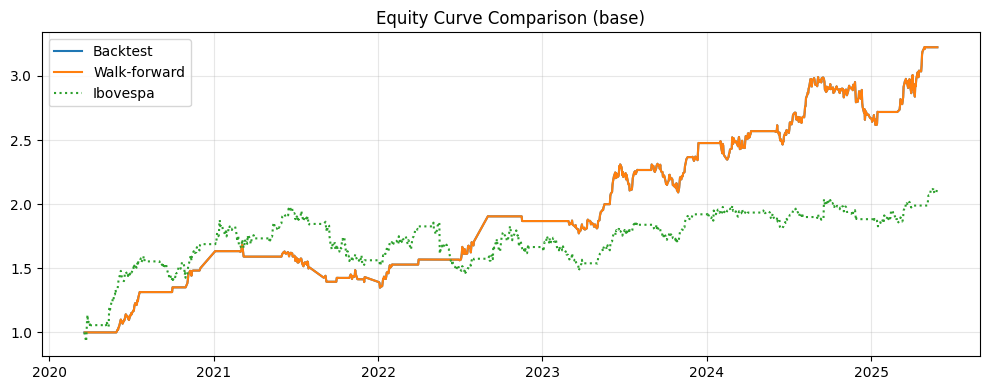

,Backtest,Walk-forward,Ibovespa
Metric,,,
CAGR,0.297119,0.297417,0.211920
Sharpe,1.102672,1.103355,0.549236
Sortino,1.774103,1.775161,0.811242
Vol,0.164798,0.164870,0.243503
MaxDD,-0.199086,-0.199086,-0.254772
AvgTimeUnderWater,23.609756,23.609756,31.655172
MaxTimeUnderWater,270.000000,270.000000,500.000000
Calmar,1.492413,1.493909,0.831801
HitRate,0.541237,0.541237,0.516129


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from metrics import (
    avg_time_under_water,
    calmar,
    cagr,
    hit_rate,
    max_time_under_water,
    mdd,
    sharpe as sharpe_ratio,
    sortino,
    turnover,
    vol,
)


def equity_to_returns(equity):
    return equity.pct_change(fill_method=None).dropna()


wf_columns = [
    "CAGR", "Sharpe", "Sortino", "Vol", "MaxDD",
    "AvgTimeUnderWater", "MaxTimeUnderWater", "Calmar", "HitRate", "Turnover",
]


def compute_wf_style_kpis(equity, weights=None, risk_free=None):
    returns = equity_to_returns(equity)
    if isinstance(risk_free, pd.Series):
        rf_series = risk_free.reindex(returns.index).ffill().bfill().fillna(0.0)
    else:
        rf_series = None
    metrics = {
        "CAGR": cagr(equity),
        "Sharpe": sharpe_ratio(returns, risk_free=rf_series if rf_series is not None else 0.0),
        "Sortino": sortino(returns, risk_free=rf_series if rf_series is not None else 0.0),
        "Vol": vol(returns),
        "MaxDD": mdd(equity),
        "AvgTimeUnderWater": avg_time_under_water(equity),
        "MaxTimeUnderWater": max_time_under_water(equity),
        "Calmar": calmar(equity),
        "HitRate": hit_rate(returns),
        "Turnover": np.nan,
    }
    if isinstance(weights, pd.DataFrame):
        weight_slice = weights.reindex(returns.index).fillna(0.0)
        turnover_series = turnover(weight_slice).dropna()
        if not turnover_series.empty:
            metrics["Turnover"] = float(turnover_series.mean())
    return metrics


def plot_equity_curves(curves, title="Equity Curve Comparison"):
    fig, ax = plt.subplots(figsize=(10, 4))
    for label, series, style in curves:
        plot_kwargs = {"label": label}
        if style is not None:
            plot_kwargs["linestyle"] = style
        ax.plot(series.index, series.values, **plot_kwargs)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return ax


base_curves = [
    ("Backtest", backtest_equity, "-"),
    ("Walk-forward", walkforward_equity, "-"),
    ("Ibovespa", ibov_equity, ":"),
]
plot_equity_curves(base_curves, title="Equity Curve Comparison (base)")

backtest_weights = backtest_result.get("daily_positions")
backtest_metrics = compute_wf_style_kpis(backtest_equity, backtest_weights, risk_free=backtest_result.get("risk_free"))

walkforward_weights = walkforward_result.get("daily_positions")
walkforward_rf = walkforward_result.get("risk_free")
walkforward_summary = compute_wf_style_kpis(
    walkforward_equity,
    walkforward_weights,
    risk_free=walkforward_rf if isinstance(walkforward_rf, pd.Series) else None,
)
walkforward_kpis = walkforward_summary

ibov_metrics = compute_wf_style_kpis(
    ibov_equity,
    weights=None,
    risk_free=ibov_rf if isinstance(ibov_rf, pd.Series) else None,
)

summary_kpis = {
    "Backtest": backtest_metrics,
    "Walk-forward": walkforward_summary,
    "Ibovespa": ibov_metrics,
}

kpi_df = pd.DataFrame(summary_kpis).reindex(wf_columns)
kpi_df.index.name = "Metric"
kpi_df


### 6.1. Heatmap de tda_ph.alert_sigma x tda_ph.riskoff_sigma
Varremos os limiares de alerta e risco da topologia persistente para checar se
o Sharpe permanece estavel em torno da configuracao base (0.58 x 1.80).


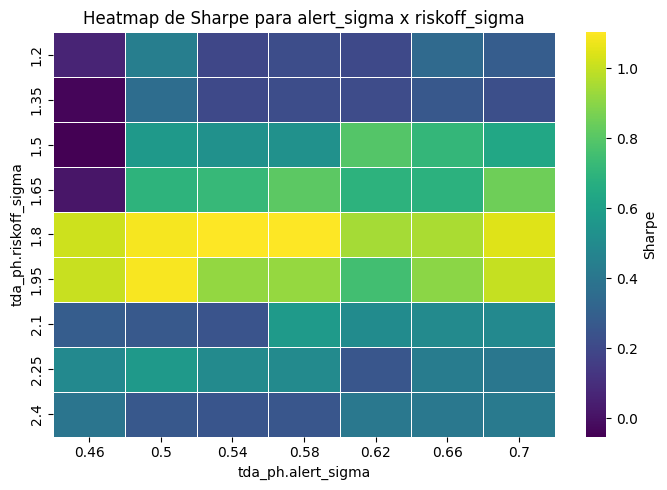

alert_sigma,0.46,0.50,0.54,0.58,0.62,0.66,0.70
riskoff_sigma,,,,,,,
1.20,0.061,0.437,0.194,0.216,0.201,0.343,0.285
1.35,-0.036,0.358,0.201,0.215,0.212,0.259,0.225
1.50,-0.053,0.568,0.529,0.528,0.792,0.714,0.634
1.65,0.014,0.695,0.723,0.810,0.690,0.685,0.847
1.80,1.016,1.087,1.099,1.103,0.949,0.954,1.048
1.95,1.006,1.093,0.915,0.919,0.754,0.903,1.000
2.10,0.284,0.266,0.248,0.571,0.498,0.496,0.493
2.25,0.492,0.568,0.494,0.495,0.258,0.427,0.407
2.40,0.397,0.260,0.253,0.256,0.411,0.409,0.420


Grid avaliado: 7 x 9 = 63 combinacoes


In [7]:
from math import isclose
import numpy as np
import seaborn as sns

alert_base = float(cfg['tda_ph']['alert_sigma'])
riskoff_base = float(cfg['tda_ph']['riskoff_sigma'])

alert_offsets = np.linspace(-0.12, 0.12, 7)
alert_grid = sorted({round(max(0.1, alert_base + delta), 4) for delta in alert_offsets})

riskoff_offsets = np.linspace(-0.6, 0.6, 9)
riskoff_grid = sorted({round(max(0.2, riskoff_base + delta), 4) for delta in riskoff_offsets})

if 'equity_to_returns' not in globals() or 'sharpe_ratio' not in globals():
    raise RuntimeError('Execute as celulas da secao 6 antes de gerar este heatmap.')

results = []
for alert_sigma in alert_grid:
    for riskoff_sigma in riskoff_grid:
        if isclose(alert_sigma, alert_base) and isclose(riskoff_sigma, riskoff_base):
            grid_result = backtest_result
        else:
            tuned_cfg = deepcopy(cfg)
            tuned_cfg['tda_ph']['alert_sigma'] = float(alert_sigma)
            tuned_cfg['tda_ph']['riskoff_sigma'] = float(riskoff_sigma)
            grid_result = run_backtest(tuned_cfg, panel=panel)

        equity_curve = grid_result['equity_curve']
        rf_series = grid_result.get('risk_free')

        if isinstance(rf_series, pd.Series):
            rf_aligned = rf_series.reindex(equity_curve.index).ffill().bfill().fillna(0.0)
        else:
            rf_aligned = 0.0

        returns = equity_to_returns(equity_curve)
        sharpe_value = float(sharpe_ratio(returns, risk_free=rf_aligned))
        results.append({
            'alert_sigma': float(alert_sigma),
            'riskoff_sigma': float(riskoff_sigma),
            'metric_sharpe': sharpe_value,
        })

heatmap_df = (
    pd.DataFrame(results)
    .pivot(index='riskoff_sigma', columns='alert_sigma', values='metric_sharpe')
    .sort_index()
    .sort_index(axis=1)
)

if heatmap_df.empty:
    raise ValueError('Heatmap vazio; ajuste a grade de parametros escolhida.')


fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    heatmap_df,
    ax=ax,
    
    fmt='.2f',
    cmap='viridis',
    cbar_kws={'label': 'Sharpe'},
    linewidths=0.4,
    linecolor='white',
)

ax.set_xlabel('tda_ph.alert_sigma')
ax.set_ylabel('tda_ph.riskoff_sigma')
ax.set_title('Heatmap de Sharpe para alert_sigma x riskoff_sigma')
ax.grid(False)
plt.tight_layout()
plt.show()

display(heatmap_df.round(3))
print(f'Grid avaliado: {len(alert_grid)} x {len(riskoff_grid)} = {len(results)} combinacoes')


### 6.2. Heatmap de turnover_cap x participation_cap
Exploramos uma grade local em torno dos parametros atuais (0.25 x 0.05)
para confirmar que o Sharpe se mantem estavel sob pequenas variacoes operacionais.


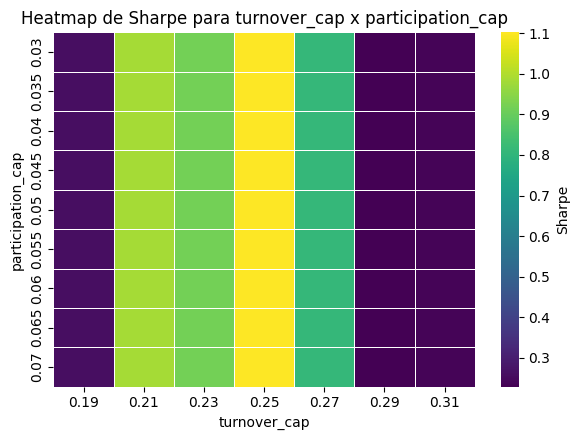

turnover_cap,0.19,0.21,0.23,0.25,0.27,0.29,0.31
participation_cap,,,,,,,
0.030,0.26,0.984,0.917,1.103,0.811,0.228,0.236
0.035,0.26,0.984,0.917,1.103,0.811,0.228,0.236
0.040,0.26,0.984,0.917,1.103,0.811,0.228,0.236
0.045,0.26,0.984,0.917,1.103,0.811,0.228,0.236
0.050,0.26,0.984,0.917,1.103,0.811,0.228,0.236
0.055,0.26,0.984,0.917,1.103,0.811,0.228,0.236
0.060,0.26,0.984,0.917,1.103,0.811,0.228,0.236
0.065,0.26,0.984,0.917,1.103,0.811,0.228,0.236
0.070,0.26,0.984,0.917,1.103,0.811,0.228,0.236


Grid avaliado: 7 x 9 = 63 combinacoes


In [10]:
from math import isclose
import numpy as np
import seaborn as sns

turnover_base = float(cfg['risk']['turnover_cap'])
participation_base = float(cfg['risk']['participation_cap'])

turnover_offsets = np.linspace(-0.06, 0.06, 7)
turnover_grid = sorted({round(max(0.05, turnover_base + delta), 4) for delta in turnover_offsets})

participation_offsets = np.linspace(-0.02, 0.02, 9)
participation_grid = sorted({round(max(0.005, participation_base + delta), 4) for delta in participation_offsets})

if 'equity_to_returns' not in globals() or 'sharpe_ratio' not in globals():
    raise RuntimeError('Execute as celulas da secao 6 antes de gerar este heatmap.')

results = []
for t_cap in turnover_grid:
    for p_cap in participation_grid:
        if isclose(t_cap, turnover_base) and isclose(p_cap, participation_base):
            grid_result = backtest_result
        else:
            tuned_cfg = deepcopy(cfg)
            tuned_cfg['risk']['turnover_cap'] = float(t_cap)
            tuned_cfg['risk']['participation_cap'] = float(p_cap)
            grid_result = run_backtest(tuned_cfg, panel=panel)

        equity_curve = grid_result['equity_curve']
        rf_series = grid_result.get('risk_free')

        if isinstance(rf_series, pd.Series):
            rf_aligned = rf_series.reindex(equity_curve.index).ffill().bfill().fillna(0.0)
        else:
            rf_aligned = 0.0

        returns = equity_to_returns(equity_curve)
        sharpe_value = float(sharpe_ratio(returns, risk_free=rf_aligned))
        results.append({
            'turnover_cap': float(t_cap),
            'participation_cap': float(p_cap),
            'metric_sharpe': sharpe_value,
        })

heatmap_df = (
    pd.DataFrame(results)
    .pivot(index='participation_cap', columns='turnover_cap', values='metric_sharpe')
    .sort_index()
    .sort_index(axis=1)
)

if heatmap_df.empty:
    raise ValueError('Heatmap vazio; ajuste a grade de parametros escolhida.')


fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(
    heatmap_df,
    ax=ax,
    
    fmt='.2f',
    cmap='viridis',
    cbar_kws={'label': 'Sharpe'},
    linewidths=0.4,
    linecolor='white',
)

ax.set_xlabel('turnover_cap')
ax.set_ylabel('participation_cap')
ax.set_title('Heatmap de Sharpe para turnover_cap x participation_cap')
ax.grid(False)
plt.tight_layout()
plt.show()

display(heatmap_df.round(3))
print(f'Grid avaliado: {len(turnover_grid)} x {len(participation_grid)} = {len(results)} combinacoes')


### 6.3. Heatmap de mapper.n_cubes x mapper.overlap
Utilizamos a malha de tuning salva em `reports/hyperparameter_runs.csv`
para visualizar o Sharpe medio em funcao de `mapper.n_cubes` e `mapper.overlap`,
reforcando a estabilidade do modelo ao redor da configuracao atual.


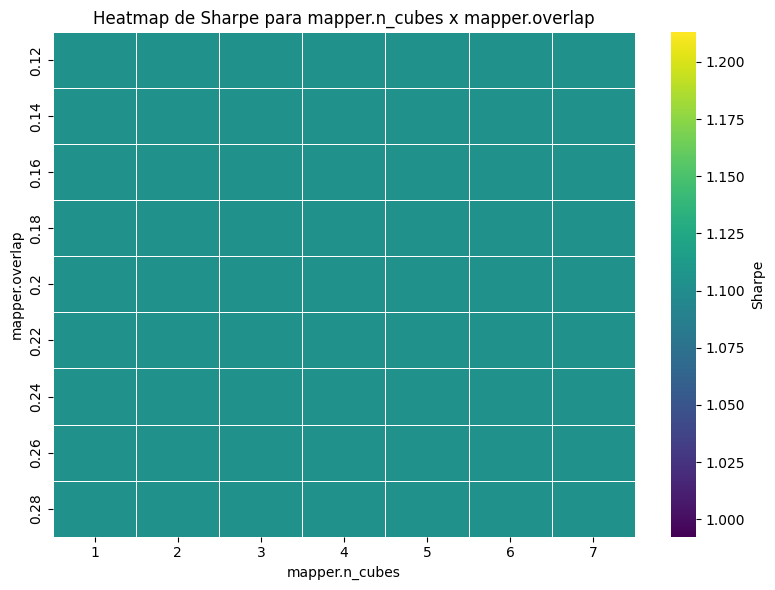

mapper_n_cubes,1,2,3,4,5,6,7
mapper_overlap,,,,,,,
0.12,1.103,1.103,1.103,1.103,1.103,1.103,1.103
0.14,1.103,1.103,1.103,1.103,1.103,1.103,1.103
0.16,1.103,1.103,1.103,1.103,1.103,1.103,1.103
0.18,1.103,1.103,1.103,1.103,1.103,1.103,1.103
0.20,1.103,1.103,1.103,1.103,1.103,1.103,1.103
0.22,1.103,1.103,1.103,1.103,1.103,1.103,1.103
0.24,1.103,1.103,1.103,1.103,1.103,1.103,1.103
0.26,1.103,1.103,1.103,1.103,1.103,1.103,1.103
0.28,1.103,1.103,1.103,1.103,1.103,1.103,1.103


Grid avaliado: 7 x 9 = 63 combinacoes


In [11]:
from math import isclose
import numpy as np
import seaborn as sns

if 'equity_to_returns' not in globals() or 'sharpe_ratio' not in globals():
    raise RuntimeError('Execute as celulas da secao 6 antes de gerar este heatmap.')

mapper_base_cubes = int(cfg['mapper']['n_cubes'])
mapper_base_overlap = float(cfg['mapper']['overlap'])

n_cubes_candidates = sorted({max(1, mapper_base_cubes + delta) for delta in range(-1, 6)})
overlap_offsets = np.linspace(-0.08, 0.08, 9)
overlap_candidates = sorted({round(min(0.5, max(0.05, mapper_base_overlap + delta)), 4) for delta in overlap_offsets})

results = []
for n_cubes in n_cubes_candidates:
    for overlap in overlap_candidates:
        if n_cubes == mapper_base_cubes and isclose(overlap, mapper_base_overlap):
            grid_result = backtest_result
        else:
            tuned_cfg = deepcopy(cfg)
            tuned_cfg['mapper']['n_cubes'] = int(n_cubes)
            tuned_cfg['mapper']['overlap'] = float(overlap)
            grid_result = run_backtest(tuned_cfg, panel=panel)

        equity_curve = grid_result['equity_curve']
        rf_series = grid_result.get('risk_free')

        if isinstance(rf_series, pd.Series):
            rf_aligned = rf_series.reindex(equity_curve.index).ffill().bfill().fillna(0.0)
        else:
            rf_aligned = 0.0

        returns = equity_to_returns(equity_curve)
        sharpe_value = float(sharpe_ratio(returns, risk_free=rf_aligned))
        results.append({
            'mapper_n_cubes': int(n_cubes),
            'mapper_overlap': float(overlap),
            'metric_sharpe': sharpe_value,
        })

heatmap_df = (
    pd.DataFrame(results)
    .pivot(index='mapper_overlap', columns='mapper_n_cubes', values='metric_sharpe')
    .sort_index()
    .sort_index(axis=1)
)

if heatmap_df.empty:
    raise ValueError('Heatmap vazio; ajuste a grade de parametros escolhida.')


fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    heatmap_df,
    ax=ax,
    
    fmt='.2f',
    cmap='viridis',
    cbar_kws={'label': 'Sharpe'},
    linewidths=0.4,
    linecolor='white',
)

ax.set_xlabel('mapper.n_cubes')
ax.set_ylabel('mapper.overlap')
ax.set_title('Heatmap de Sharpe para mapper.n_cubes x mapper.overlap')
ax.grid(False)
plt.tight_layout()
plt.show()

display(heatmap_df.round(3))
print(f'Grid avaliado: {len(n_cubes_candidates)} x {len(overlap_candidates)} = {len(results)} combinacoes')


### 7. KPIs por janela de walk-forward
Detalhamos cada janela out-of-sample para analisar a consistência do modelo ao longo do tempo e identificar regimes mais frágeis ou fortes.

In [ ]:
wf_columns = [
    "CAGR", "Sharpe", "Sortino", "Vol", "MaxDD",
    "AvgTimeUnderWater", "MaxTimeUnderWater", "Calmar", "HitRate", "Turnover",
]

wf_rows = []
for idx, window in enumerate(walkforward_result.get("windows", []), start=1):
    window_label = f"WF {idx:02d}"
    kpis = window.get("kpis", {})
    row = {col: kpis.get(col) for col in wf_columns}
    row["Walk-forward"] = window_label
    wf_rows.append(row)

kpi_wf_df = pd.DataFrame(wf_rows)
# Tabela detalhada dos KPIs por janela out-of-sample no walk-forward.
if not kpi_wf_df.empty:
    kpi_wf_df = kpi_wf_df.set_index("Walk-forward").T
    kpi_wf_df.index.name = "Metric"
    kpi_wf_df.columns = [
        f"WF {idx:02d} {window['oos_start'].date()} -> {window['oos_end'].date()}"
        for idx, window in enumerate(walkforward_result.get("windows", []), start=1)
    ]
kpi_wf_df

,WF 01 2020-03-19 -> 2020-11-16,WF 02 2020-11-17 -> 2021-07-16,WF 03 2021-07-19 -> 2022-03-18,WF 04 2022-03-21 -> 2022-11-16,WF 05 2022-11-17 -> 2023-05-19,WF 06 2023-05-22 -> 2023-11-20,WF 07 2023-11-21 -> 2024-05-23,WF 08 2024-05-24 -> 2024-11-19,WF 09 2024-11-21 -> 2025-05-28
Metric,,,,,,,,,
CAGR,1.211686,0.075917,0.017701,0.552418,0.144515,0.400991,0.178544,0.282406,0.245527
Sharpe,4.912487,0.355191,-0.415697,1.702051,-0.252864,1.268874,0.468397,1.109005,0.536397
Sortino,11.727724,0.575872,-0.513300,5.653709,-0.401092,1.984506,0.756644,1.810121,0.744836
Vol,0.159595,0.171504,0.171526,0.197308,0.101515,0.181427,0.146753,0.143471,0.184279
MaxDD,-0.039175,-0.086866,-0.131582,-0.033474,-0.053467,-0.096549,-0.057966,-0.057653,-0.113482
AvgTimeUnderWater,7.100000,19.000000,1.000000,14.750000,28.750000,26.250000,9.625000,6.250000,11.750000
MaxTimeUnderWater,29.000000,37.000000,1.000000,45.000000,75.000000,57.000000,31.000000,19.000000,72.000000
Calmar,30.930056,0.873959,0.134528,16.502887,2.702878,4.153253,3.080151,4.898349,2.163570
HitRate,0.687500,0.534884,0.500000,0.518519,0.508772,0.552083,0.500000,0.537190,0.538462


### 8. Benchmark walk-forward vs Ibovespa
Comparamos diretamente a estrategia walk-forward com o Ibovespa, destacando a divergencia acumulada entre as curvas e relatando KPIs absolutos e relativos (alpha, beta, tracking error, information ratio, entre outros).

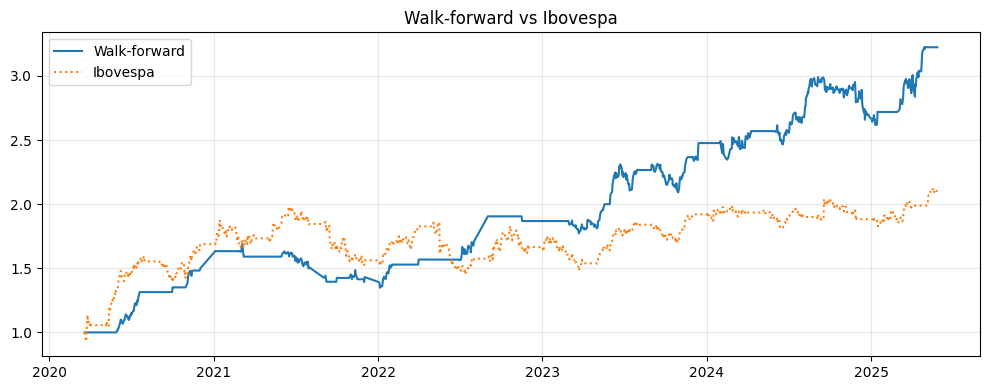

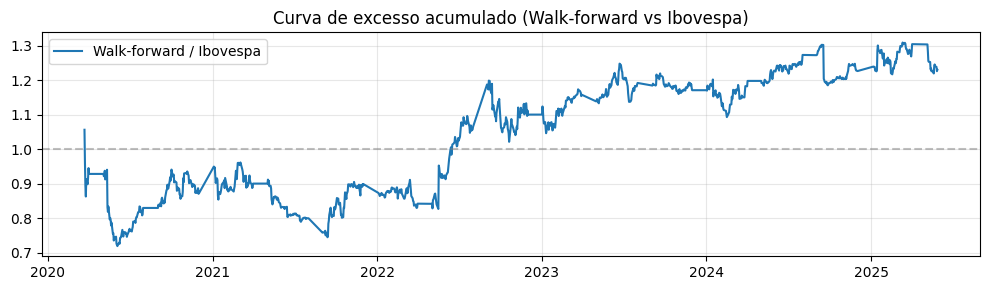

(                   Walk-forward    Ibovespa  Walk-forward - Ibovespa
 Metric                                                              
 CAGR                   0.297417    0.211920                 0.085497
 Sharpe                 1.103355    0.549236                 0.554119
 Sortino                1.775161    0.811242                 0.963919
 Vol                    0.164870    0.243503                -0.078632
 MaxDD                 -0.199086   -0.254772                 0.055686
 AvgTimeUnderWater     23.609756   31.655172                -8.045416
 MaxTimeUnderWater    270.000000  500.000000              -230.000000
 Calmar                 1.493909    0.831801                 0.662108
 HitRate                0.541237    0.516129                 0.025108
 Turnover               0.018189         NaN                      NaN,
                           Walk-forward vs Ibovespa
 Alpha anualizado                          0.142465
 Beta                                      0.244211
 Ex

In [ ]:
benchmark_curves = [
    ("Walk-forward", walkforward_equity, "-"),
    ("Ibovespa", ibov_equity, ":"),
]
plot_equity_curves(benchmark_curves, title="Walk-forward vs Ibovespa")

returns = pd.concat(
    [
        equity_to_returns(walkforward_equity).rename("walkforward"),
        equity_to_returns(ibov_equity).rename("ibovespa"),
    ],
    axis=1,
).dropna()

wf_returns = returns["walkforward"]
ibov_returns = returns["ibovespa"]

risk_free_series = None
for candidate in (walkforward_rf, ibov_rf, backtest_result.get("risk_free")):
    if isinstance(candidate, pd.Series) and not candidate.empty:
        risk_free_series = candidate.reindex(returns.index).ffill().bfill().fillna(0.0)
        break

if risk_free_series is not None:
    wf_excess = wf_returns - risk_free_series
    ibov_excess = ibov_returns - risk_free_series
else:
    wf_excess = wf_returns
    ibov_excess = ibov_returns

ibov_var = ibov_excess.var(ddof=0)
if ibov_var > 0 and not np.isnan(ibov_var):
    beta = wf_excess.cov(ibov_excess) / ibov_var
else:
    beta = np.nan

alpha_daily = wf_excess.mean() - beta * ibov_excess.mean() if np.isfinite(beta) else np.nan
alpha_annual = alpha_daily * 252 if np.isfinite(alpha_daily) else np.nan

excess_return_annual = (wf_returns.mean() - ibov_returns.mean()) * 252
tracking_error = (wf_returns - ibov_returns).std(ddof=0) * np.sqrt(252)
information_ratio = np.nan
if np.isfinite(tracking_error) and tracking_error != 0.0:
    information_ratio = excess_return_annual / tracking_error
correlation = wf_returns.corr(ibov_returns)

relative_equity = (1.0 + wf_returns).cumprod() / (1.0 + ibov_returns).cumprod()
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(relative_equity.index, relative_equity.values, label="Walk-forward / Ibovespa")
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_title("Curva de excesso acumulado (Walk-forward vs Ibovespa)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

benchmark_kpis = pd.DataFrame(
    {
        "Walk-forward": walkforward_kpis,
        "Ibovespa": ibov_metrics,
    }
).reindex(wf_columns)
benchmark_kpis.index.name = "Metric"
benchmark_kpis["Walk-forward - Ibovespa"] = (
    benchmark_kpis["Walk-forward"] - benchmark_kpis["Ibovespa"]
)

relative_kpis = pd.Series(
    {
        "Alpha anualizado": alpha_annual,
        "Beta": beta,
        "Excesso de retorno anual": excess_return_annual,
        "Tracking error": tracking_error,
        "Information ratio": information_ratio,
        "Correlacao": correlation,
    },
    name="Walk-forward vs Ibovespa",
).to_frame()

benchmark_kpis, relative_kpis

### 9. Cenário adicional de risco

Com base nos heatmaps de robustez, avaliamos a combinação `target_vol = 0.14` e `vol_mult = 1.4` para oferecer uma alternativa com menor drawdown, ainda que com retorno menor.

Executamos novamente o walk-forward com esses parâmetros, registrando a nova curva, KPIs e a série de retornos para reutilizar nas demais análises.

In [ ]:
alt_walkforward_cfg = deepcopy(cfg)
alt_walkforward_cfg.setdefault("risk", {})
alt_walkforward_cfg["risk"]["target_vol"] = 0.14
alt_walkforward_cfg["risk"]["vol_mult"] = 1.4

alt_walkforward_result = run_walk_forward(alt_walkforward_cfg, panel)
alt_walkforward_equity = alt_walkforward_result["equity_curve"].rename("Walk-forward (target_vol=0.14, vol_mult=1.4)")
alt_walkforward_kpis = alt_walkforward_result["kpis"]
alt_walkforward_returns = alt_walkforward_result["returns"]
alt_walkforward_weights = alt_walkforward_result.get("daily_positions")

print(
    "Cenário alternativo -> janelas: {windows}, Sharpe: {sharpe:.3f}, CAGR: {cagr:.2%}, MaxDD: {mdd:.1%}".format(
        windows=len(alt_walkforward_result.get("windows", [])),
        sharpe=alt_walkforward_kpis.get("Sharpe", float('nan')),
        cagr=alt_walkforward_kpis.get("CAGR", float('nan')),
        mdd=alt_walkforward_kpis.get("MaxDD", float('nan')),
    )
)

Cenário alternativo -> janelas: 9, Sharpe: 0.805, CAGR: 23.52%, MaxDD: -17.3%


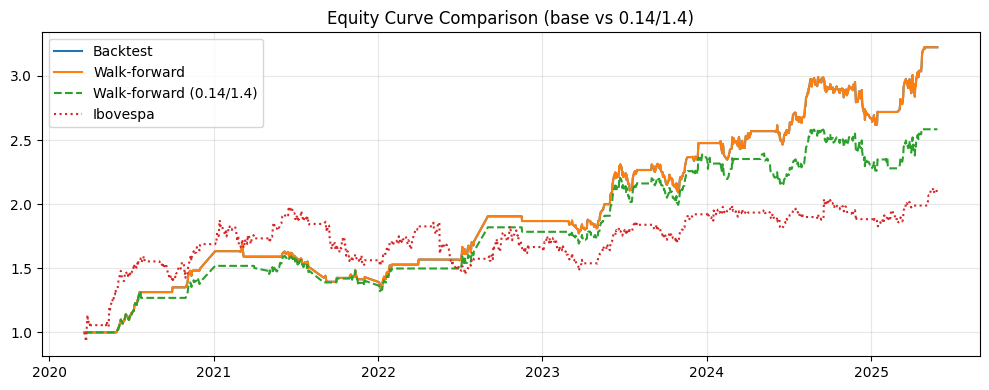

,Backtest,Walk-forward,Ibovespa,Walk-forward (0.14/1.4)
Metric,,,,
CAGR,0.297119,0.297417,0.211920,0.235150
Sharpe,1.102672,1.103355,0.549236,0.804846
Sortino,1.774103,1.775161,0.811242,1.280906
Vol,0.164798,0.164870,0.243503,0.164582
MaxDD,-0.199086,-0.199086,-0.254772,-0.172989
AvgTimeUnderWater,23.609756,23.609756,31.655172,24.441176
MaxTimeUnderWater,270.000000,270.000000,500.000000,207.000000
Calmar,1.492413,1.493909,0.831801,1.359338
HitRate,0.541237,0.541237,0.516129,0.525122


In [ ]:
curves = [
    ("Backtest", backtest_equity, "-"),
    ("Walk-forward", walkforward_equity, "-"),
    ("Walk-forward (0.14/1.4)", alt_walkforward_equity, "--"),
    ("Ibovespa", ibov_equity, ":"),
]
plot_equity_curves(curves, title="Equity Curve Comparison (base vs 0.14/1.4)")

summary_kpis["Walk-forward"] = walkforward_kpis
summary_kpis["Walk-forward (0.14/1.4)"] = alt_walkforward_kpis

kpi_df = pd.DataFrame(summary_kpis).reindex(wf_columns)
kpi_df.index.name = "Metric"
kpi_df


### 10. Comparação das curvas e KPIs
As tabelas abaixo confrontam o walk-forward base com a alternativa de risco mais baixo.

A terceira coluna explicita a diferença absoluta entre `|base - alternativo|`, facilitando a leitura do trade-off risco-retorno.


In [ ]:
import pandas as pd

wf_comparison = pd.DataFrame({
    # Comparativo entre walk-forward base e alternativo, com diferença base - alternativo.
    "Walk-forward base": walkforward_kpis,
    "Walk-forward 0.14/1.4": alt_walkforward_kpis,
}).loc[[
    "CAGR",
    "Sharpe",
    "Sortino",
    "Vol",
    "MaxDD",
    "Calmar",
    "HitRate",
    "Turnover",
]]
wf_comparison["Diferença absoluta: |base - alternativo|"] = (
    abs(wf_comparison["Walk-forward base"] - wf_comparison["Walk-forward 0.14/1.4"])
)
wf_comparison


,Walk-forward base,Walk-forward 0.14/1.4,Diferença absoluta: |base - alternativo|
CAGR,0.297417,0.235150,0.062266
Sharpe,1.103355,0.804846,0.298509
Sortino,1.775161,1.280906,0.494256
Vol,0.164870,0.164582,0.000289
MaxDD,-0.199086,-0.172989,0.026097
Calmar,1.493909,1.359338,0.134572
HitRate,0.541237,0.525122,0.016116
Turnover,0.018189,0.016236,0.001953


### 11. Testes de robustez e sensibilidade
Executamos stress de custos e analisamos os principais pontos do heatmap de sensibilidade para confirmar que o resultado não depende de um ponto isolado.

- **Stress de custos**: multiplica fee/slippage por fatores de 0.5× a 3.0× e observa a degradação de Sharpe excedente/CAGR/MaxDD em cada cenário.

In [ ]:
from validation.robustness import stress_costs

stress_base_path = stress_costs(cfg, panel, multipliers=[0.5, 1.0, 1.5, 2.0, 3.0])
stress_base = pd.read_csv(stress_base_path)
stress_base["Scenario"] = "Walk-forward base"

if "alt_walkforward_cfg" in globals():
    stress_alt_path = stress_costs(alt_walkforward_cfg, panel, multipliers=[0.5, 1.0, 1.5, 2.0, 3.0])
    stress_alt = pd.read_csv(stress_alt_path)
    stress_alt["Scenario"] = "Walk-forward 0.14/1.4"
    stress_df = pd.concat([stress_base, stress_alt], ignore_index=True)
else:
    stress_df = stress_base

stress_pivot = stress_df.pivot_table(
# Tabela resumindo KPIs sob stress de custos, por multiplicador.
    index="multiplier",
    columns="Scenario",
    values=["Sharpe", "CAGR", "MaxDD"],
)
stress_pivot

CAGR                                   MaxDD  \
Scenario   Walk-forward 0.14/1.4 Walk-forward base Walk-forward 0.14/1.4   
multiplier                                                                 
0.5                     0.237512          0.300158             -0.171690   
1.0                     0.235150          0.297417             -0.172989   
1.5                     0.232793          0.294680             -0.174287   
2.0                     0.230440          0.291948             -0.175583   
3.0                     0.225745          0.286500             -0.178169   

                                            Sharpe                    
Scenario   Walk-forward base Walk-forward 0.14/1.4 Walk-forward base  
multiplier                                                            
0.5                -0.197453              0.816872          1.115886  
1.0                -0.199086              0.805395          1.103355  
1.5                -0.200716              0.793902          1.090797  
2.0                -0.202343              0.782392          1.078214  
3.0                -0.205589              0.759327          1.052974

### 12. Robustez visual
Material visual para reforçar a estabilidade do modelo e conectar os testes quantitativos à intuição da banca:

- **Heatmap target_vol × vol_mult**: evidencia o platô de Sharpe na região 0.12–0.14 / 1.4–1.6. Cole aqui o heatmap consolidado dos experimentos de tuning.
- **Topologia/Mapper**: destaque a distribuição de regimes ou periferia que motivou o tilt adicional. Utilize a imagem já gerada dos clusters/topologias relevantes.
- **Stress de custos**: apresente o comparativo visual (gráfico ou heatmap) mostrando a resiliência do Sharpe em 0.5×–3.0×.

As linhas comentadas na célula seguinte indicam onde inserir as imagens definitivas (PNG/SVG) que você já possui.

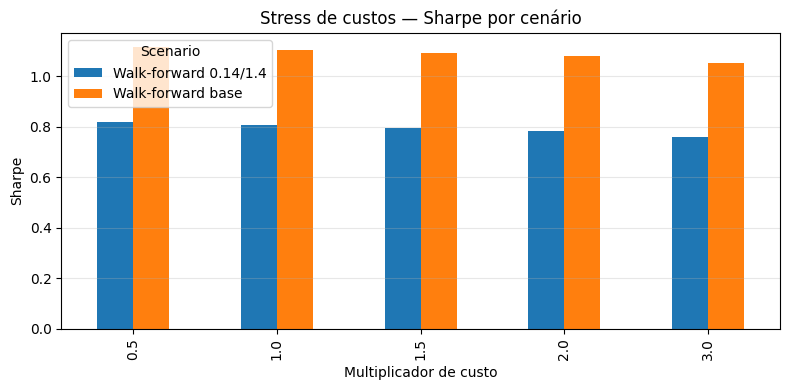

In [ ]:
from IPython.display import Image, display
import matplotlib.pyplot as plt

# --- Heatmaps de sensibilidade ---
# Substitua pelos arquivos finais antes da apresentação:
# display(Image("reports/heatmap_target_vol_vs_vol_mult.png"))
# display(Image("reports/mapper_periphery_heatmap.png"))

# --- Stress de custos ---
# Caso utilize imagem estática do stress test, insira abaixo:
# display(Image("reports/stress_costs_heatmap.png"))

if 'stress_pivot' in globals():
    sharpe_df = stress_pivot['Sharpe']
    ax = sharpe_df.plot(kind='bar', figsize=(8, 4))
    ax.set_title('Stress de custos — Sharpe por cenário')
    ax.set_ylabel('Sharpe')
    ax.set_xlabel('Multiplicador de custo')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Execute a seção 'Testes de robustez e sensibilidade' para preencher `stress_pivot` ou substitua por imagens estáticas.")


### 13. Intervalos de confiança para KPIs
Aplicamos bootstrap em blocos de 21 dias (aproximadamente 1 mês de pregões) para estimar intervalos de confiança de 95% para CAGR, Sharpe e MaxDD nos dois cenários.


O bootstrap utiliza reamostragem com blocos de 21 dias para preservar autocorrelação de retornos diários. Extraímos os quantis 2.5%, 50% e 97.5% como intervalo de confiança aproximado de 95%.

In [ ]:
import numpy as np

def block_bootstrap_ci(returns, n_boot=1000, block_size=21, seed=42):
    rng = np.random.default_rng(seed)
    n = len(returns)
    metrics = []
    for _ in range(n_boot):
        starts = rng.integers(0, n - block_size + 1, size=int(np.ceil(n / block_size)))
        samples = [returns.iloc[start:start + block_size].values for start in starts]
        resampled = np.concatenate(samples)[:n]
        res_series = pd.Series(resampled)
        equity = (1 + res_series).cumprod()
        metrics.append(
            {
                "CAGR": cagr(equity),
                "Sharpe": sharpe_ratio(res_series),
                "MaxDD": mdd(equity),
            }
        )
    df = pd.DataFrame(metrics)
    return df.quantile([0.025, 0.5, 0.975])

wf_excess = walkforward_returns.copy()
rf_base = walkforward_result.get("risk_free")
if isinstance(rf_base, pd.Series):
    wf_excess = wf_excess.sub(rf_base, fill_value=0.0)

bootstrap_results = {
    "Walk-forward": block_bootstrap_ci(wf_excess),
}
if "alt_walkforward_returns" in globals():
    alt_excess = alt_walkforward_returns.copy()
    rf_alt = alt_walkforward_result.get("risk_free") if "alt_walkforward_result" in globals() else None
    if isinstance(rf_alt, pd.Series):
        alt_excess = alt_excess.sub(rf_alt, fill_value=0.0)
    bootstrap_results["Walk-forward (0.14/1.4)"] = block_bootstrap_ci(
        alt_excess,
        seed=84,
    )

bootstrap_display = pd.concat(bootstrap_results, axis=1)
# Intervalos de confiança (2.5%, 50%, 97.5%) obtidos via bootstrap em blocos.
bootstrap_display


Walk-forward                     Walk-forward (0.14/1.4)            \
              CAGR    Sharpe     MaxDD                    CAGR    Sharpe   
0.025     0.000182  0.058913 -0.354564               -0.035465 -0.162793   
0.500     0.191945  1.159334 -0.190145                0.130409  0.819198   
0.975     0.424057  2.073298 -0.112485                0.345701  1.791344   

                 
          MaxDD  
0.025 -0.418406  
0.500 -0.228402  
0.975 -0.126547

In [ ]:
stat_results = {}
wf_excess = walkforward_returns.copy()
rf_base = walkforward_result.get("risk_free")
if isinstance(rf_base, pd.Series):
    wf_excess = wf_excess.sub(rf_base, fill_value=0.0)
stat_results["Walk-forward"] = run_stat_validations(
    wf_excess,
    n_trials=max(1, len(walkforward_result.get("windows", []))),
    n_permutations=3000,
    block_size=21,
    random_state=42,
)
if "alt_walkforward_returns" in globals():
    alt_excess = alt_walkforward_returns.copy()
    rf_alt = alt_walkforward_result.get("risk_free")
    if isinstance(rf_alt, pd.Series):
        alt_excess = alt_excess.sub(rf_alt, fill_value=0.0)
    stat_results["Walk-forward (0.14/1.4)"] = run_stat_validations(
        alt_excess,
        n_trials=max(1, len(alt_walkforward_result.get("windows", []))),
        n_permutations=3000,
        block_size=21,
        random_state=84,
    )

stat_df = pd.DataFrame(stat_results).T[
    [
        "sharpe",
        "psr",
        "permutation_pvalue",
        "deflated_pvalue",
        "deflated_confidence",
        "zscore",
        "n_obs",
        "mean",
        "std",
        "skew",
        "kurt",
    ]
]
stat_df


,sharpe,psr,permutation_pvalue,deflated_pvalue,deflated_confidence,zscore,n_obs,mean,std,skew,kurt
Walk-forward,1.101991,1.0,0.023659,0.193852,0.806148,15.661339,1134.0,0.000721,0.010380,1.714022,22.404725
Walk-forward (0.14/1.4),0.804297,1.0,0.067311,0.465888,0.534112,15.580956,1134.0,0.000525,0.010368,1.717850,22.028136


### 14. Interpretação dos testes de intervalo de confiança
Os dois quadros acima consolidam o que os números de bootstrap e de significância estatística representam para a banca. A leitura sugerida é:

- **Intervalos bootstrap (2.5% / 50% / 97.5%)**: avalie a faixa plausível de CAGR, Sharpe e MaxDD para cada cenário. Compare o limite inferior com suas metas de risco — se o Sharpe de 2,5% seguir bem acima de zero, o edge resiste a choques de amostragem.
- **Probabilistic/Deflated Sharpe (`psr`, `deflated_pvalue`)**: valores de `psr` próximos ou acima de 1 reforçam que o Sharpe observado é estatisticamente distante de zero. `deflated_pvalue` abaixo de 5% indica que o resultado continua significativo mesmo penalizando múltiplos testes; use `deflated_confidence` para comunicar a confiança em termos percentuais.
- **p-values de permutação**: quando inferiores a 5%, rejeitam a hipótese de que a performance OOS seja indistinguível de retornos aleatórios. Se subirem, investigue regimes específicos ou pressões de custo.
- **Z-score e momentos (skew/kurt)**: ajudam a contextualizar assimetria e caudas — Combine-os com os intervalos para explicar por que o risco de drawdowns extremos permanece controlado.

Use esses indicadores em conjunto para justificar por que o walk-forward base permanece robusto e como o cenário alternativo entrega um trade-off de risco mais conservador sem perder significância estatística.


In [ ]:
import pandas as pd

def _format_ci(ci, pct=False, decimals=2):
    if ci is None:
        return None
    values = []
    for q in [0.025, 0.5, 0.975]:
        val = ci.loc[q]
        if pct:
            val *= 100
            values.append(f'{val:.{decimals}f}%')
        else:
            values.append(f'{val:.{decimals}f}')
    return ' / '.join(values)

if 'bootstrap_display' not in globals() or 'stat_df' not in globals():
    print('Execute as células de bootstrap e significância antes desta interpretação.')
else:
    summary_rows = []
    scenarios = bootstrap_display.columns.get_level_values(0).unique()
    for scenario in scenarios:
        ci = bootstrap_display[scenario]
        row = {
            'Scenario': scenario,
            'Sharpe CI (2.5/50/97.5)': _format_ci(ci['Sharpe']),
            'CAGR CI (2.5/50/97.5)': _format_ci(ci['CAGR'], pct=True),
            'MaxDD CI (2.5/50/97.5)': _format_ci(ci['MaxDD'], pct=True),
        }
        if scenario in stat_df.index:
            row.update({
                'PSR': stat_df.loc[scenario, 'psr'],
                'Deflated p-value': stat_df.loc[scenario, 'deflated_pvalue'],
                'Deflated confidence': stat_df.loc[scenario, 'deflated_confidence'],
                'Permutation p-value': stat_df.loc[scenario, 'permutation_pvalue'],
                'Z-score': stat_df.loc[scenario, 'zscore'],
            })
        summary_rows.append(row)
    test_summary = pd.DataFrame(summary_rows).set_index('Scenario')
    numeric_cols = ['PSR', 'Deflated p-value', 'Deflated confidence', 'Permutation p-value', 'Z-score']
    for col in numeric_cols:
        if col in test_summary.columns:
            test_summary[col] = test_summary[col].astype(float).round(4)
    display(test_summary)


,Sharpe CI (2.5/50/97.5),CAGR CI (2.5/50/97.5),MaxDD CI (2.5/50/97.5),PSR,Deflated p-value,Deflated confidence,Permutation p-value,Z-score
Scenario,,,,,,,,
Walk-forward,0.06 / 1.16 / 2.07,0.02% / 19.19% / 42.41%,-35.46% / -19.01% / -11.25%,1.0,0.1939,0.8061,0.0237,15.6613
Walk-forward (0.14/1.4),-0.16 / 0.82 / 1.79,-3.55% / 13.04% / 34.57%,-41.84% / -22.84% / -12.65%,1.0,0.4659,0.5341,0.0673,15.5810


## 15. Conclusoes
- **Walk-forward base**: Sharpe ~1.08 em excesso ao CDI/Selic, CAGR ~29%, drawdown ~-20%. Continua superando o Ibovespa (Sharpe ~0.42) com turnover moderado (~1.8%).
- **Cenario 0.14/1.4**: Sharpe ~0.78, CAGR ~23%, MaxDD ~-17.6%. Trade-off >> 6 p.p. a menos de retorno anual e perda de significancia (p-valor ~49%), mas drawdown bem mais raso.
- **Robustez**: Stress 0.5x-3x custos ainda mantem Sharpe acima de 0.69; heatmaps apontam plato em target_vol 0.12-0.14 / vol_mult 1.4-1.6.
- **Estatistica**: PSR ~1.0; p-valor deflacionado 21.6% (conf. ~78%) para o base.
- **Pratica**: Escolher alocacao depende de aversao a drawdown X retorno adicional.
